In [25]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)


In [26]:
dataframe = pd.read_csv("../data/churn_model_dataset.csv")
df = dataframe.copy()

In [27]:
df.head()

,Tenure Months,Monthly Charges,Total Charges,charge_per_tenure,num_additional_services,tenure_bucket,Contract,Churn Value
0,2,53.85,108.15,17.950000,2,0-12,Month-to-month,1
1,2,70.70,151.65,23.566667,0,0-12,Month-to-month,1
2,8,99.65,820.50,11.072222,3,0-12,Month-to-month,1
3,28,104.80,3046.05,3.613793,4,25-48,Month-to-month,1
4,49,103.70,5036.30,2.074000,4,49-72,Month-to-month,1


In [28]:
y = df["Churn Value"]

numeric_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "charge_per_tenure",
    "num_additional_services"
]

categorical_features = [
    "Contract",
    "tenure_bucket"
]

X = df[
    numeric_features + categorical_features
].copy()


here seprating validation data for ddeciding threshold optimal for miinimizig missing churners

In [29]:
# First: 80% train+validation, 20% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Second: split the 80% into:
# 64% training
# 16% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=42
)


print("Dataset sizes")
print("=" * 50)
print(f"Training   : {len(X_train)}")
print(f"Validation : {len(X_val)}")
print(f"Test       : {len(X_test)}")


Dataset sizes
Training   : 4507
Validation : 1127
Test       : 1409


In [ ]:

preprocessor = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        numeric_features
    ),
    (
        "cat",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    )
])

pipe = Pipeline([
    ("prep", preprocessor),
    (
        "clf",
        LogisticRegression(
            max_iter=1000,
            C=1.0,
            random_state=42
        )
    )
])

In [31]:
pipe.fit(X_train, y_train) # training the model pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Tenure Months','Monthly Charges','Total Charges',..., 'num_additional_services','Contract','tenure_bucket']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [32]:
val_probs = pipe.predict_proba(
    X_val
)[:, 1]



here i am chosing cost. of missed churners as business cost so calculating threshold to low the missed churners (false negative)
- Business assumption:

- Missing a churner (False Negative) is very expensive.
- Contacting a non-churner unnecessarily (False Positive)
- has a smaller cost.

Example:
- FN cost = $100
-  FP cost = $10

In [33]:
FN_COST = 100
FP_COST = 10


thresholds = np.arange(
    0.01,
    1.00,
    0.01
)

threshold_results = []


for threshold in thresholds:

    val_preds = (
        val_probs >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        val_preds
    ).ravel()

    total_cost = (
        FN_COST * fn +
        FP_COST * fp
    )

    precision = precision_score(
        y_val,
        val_preds,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_preds,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_preds,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "total_cost": total_cost
    })


threshold_results = pd.DataFrame(
    threshold_results
)

In [34]:
best_row = threshold_results.loc[
    threshold_results["total_cost"].idxmin()
]

chosen_threshold = best_row["threshold"]


print("\nTHRESHOLD SELECTION")
print("=" * 50)

print(
    f"Optimal Threshold : "
    f"{chosen_threshold:.2f}"
)

print(
    f"Validation Cost   : "
    f"${best_row['total_cost']:,.0f}"
)

print(
    f"Validation FN     : "
    f"{best_row['FN']}"
)

print(
    f"Validation FP     : "
    f"{best_row['FP']}"
)

print(
    f"Validation Recall : "
    f"{best_row['recall']:.3f}"
)

print(
    f"Validation F1     : "
    f"{best_row['f1']:.3f}"
)


THRESHOLD SELECTION
Optimal Threshold : 0.05
Validation Cost   : $6,290
Validation FN     : 6.0
Validation FP     : 569.0
Validation Recall : 0.980
Validation F1     : 0.505


### Final prediction according to optimal thhreshold

In [35]:
test_probs = pipe.predict_proba(
    X_test
)[:, 1]



test_preds = (
    test_probs >= chosen_threshold
).astype(int)

In [36]:
#final metrics

precision = precision_score(
    y_test,
    test_preds,
    zero_division=0
)

recall = recall_score(
    y_test,
    test_preds,
    zero_division=0
)

f1 = f1_score(
    y_test,
    test_preds,
    zero_division=0
)

pr_auc = average_precision_score(
    y_test,
    test_probs
)


####  Final model results:

In [37]:
#final results
print("\n")
print("FINAL MODEL — TEST SET")
print("=" * 50)

print(
    f"Threshold : {chosen_threshold:.2f}"
)

print(
    f"Precision : {precision:.3f}"
)

print(
    f"Recall    : {recall:.3f}"
)

print(
    f"F1 Score  : {f1:.3f}"
)

print(
    f"PR-AUC    : {pr_auc:.3f}"
)





FINAL MODEL — TEST SET
Threshold : 0.05
Precision : 0.342
Recall    : 0.984
F1 Score  : 0.508
PR-AUC    : 0.645


In [38]:
#classification report
print("\nClassification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        test_preds,
        target_names=[
            "No Churn",
            "Churn"
        ],
        zero_division=0
    )
)



Classification Report
              precision    recall  f1-score   support

    No Churn       0.98      0.32      0.48      1035
       Churn       0.34      0.98      0.51       374

    accuracy                           0.49      1409
   macro avg       0.66      0.65      0.49      1409
weighted avg       0.81      0.49      0.49      1409




Confusion Matrix


<Axes: >

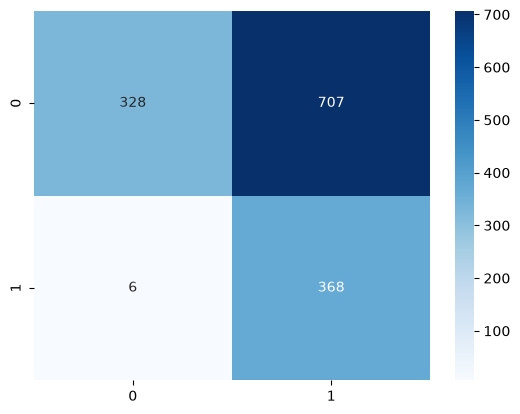

In [48]:

cm = confusion_matrix(
    y_test,
    test_preds
)

print("\nConfusion Matrix")
print("=" * 50)

df_cm = pd.DataFrame(cm)
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues")

### why this decision thresholdd

Because my business objective is to minimize the cost of missing churners, I evaluate multiple probability thresholds on a validation set and calculate the business cost at each threshold using a higher penalty for false negatives than false positives. I select the threshold with the minimum total cost and then apply that fixed threshold to the untouched test set."

## Question:

Write a short (half-page) summary: what the model gets right, one concrete failure mode, and one thing you'd monitor if this ran in production. now help writing me thhis: 


The Logistic Regression model performs well at identifying customers who are likely to churn, particularly when the classification threshold is adjusted to reflect the business objective. Instead of using the default 0.50 threshold, the threshold was selected using a validation set and a business cost function that assigns a higher cost to false negatives than false positives. This allows the model to prioritize identifying potential churners and achieve higher recall. The model's performance is evaluated using precision, recall, F1-score, PR-AUC, and the confusion matrix to understand both its predictive performance and the business impact of its decisions.

One concrete failure mode is that the model can incorrectly classify non-churning customers as churners when a lower threshold is used. These false positives may result in unnecessary retention actions, such as discounts, offers, or customer outreach. This trade-off is important because lowering the threshold helps reduce missed churners (false negatives), but can also increase false positives and reduce precision. Therefore, the selected threshold represents a balance between catching more churners and controlling unnecessary intervention costs.

If this model were deployed in production, I would closely monitor **data and prediction drift**, particularly the distribution of predicted churn probabilities and the proportion of customers classified as churners. Changes in customer behavior, pricing, contracts, or service usage could cause the model's predictions to become less reliable over time. I would also periodically monitor the false-negative rate and business cost once actual churn outcomes become available, because an increase in missed churners would directly indicate that the model may need to be retrained or its threshold reconsidered.
